In [1]:
%matplotlib inline
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

## 2 多层感知机

### 2.1 理论计算题

<img src="./hw02_pic/2-1.png" width="600">
<img src="./hw02_pic/2-2.png" width="600">
<img src="./hw02_pic/2-3.png" width="600">

### 2.2 编程题


In [2]:
# 加载 Fashion-MNIST 数据集
def load_fashion_mnist(batch_size=256, val_size=10000):
    transform = transforms.ToTensor()
    train_full = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
    test_set = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

    train_size = len(train_full) - val_size
    train_set, val_set = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

    train_iter = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    val_iter = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0)
    test_iter = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_iter, val_iter, test_iter

train_iter, val_iter, test_iter = load_fashion_mnist(batch_size=256)
len(train_iter), len(val_iter), len(test_iter)


  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



(196, 40, 40)

In [ ]:
# 定义模型参数和函数

# 手动初始化隐藏层参数和输出层参数(使用正态分布随机初始化)
def init_params(num_inputs=784, num_hiddens=256, num_outputs=10, std=0.01, device=device):
    W1 = torch.normal(0, std, size=(num_inputs, num_hiddens), device=device, requires_grad=True)
    b1 = torch.zeros(num_hiddens, device=device, requires_grad=True)
    W2 = torch.normal(0, std, size=(num_hiddens, num_outputs), device=device, requires_grad=True)
    b2 = torch.zeros(num_outputs, device=device, requires_grad=True)
    return [W1, b1, W2, b2]

# 实现 ReLU 激活函数的前向传播
def relu(X):
    return torch.clamp(X, min=0.0)

def softmax(X):
    X_shift = X - X.max(dim=1, keepdim=True).values
    X_exp = torch.exp(X_shift)
    return X_exp / X_exp.sum(dim=1, keepdim=True)

def dropout_layer(X, dropout, is_training=True):
    if (not is_training) or dropout == 0.0:
        return X
    if dropout == 1.0:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)

def net(X, params, dropout=0.0, is_training=True):
    W1, b1, W2, b2 = params
    X = X.reshape(X.shape[0], -1)
    H = relu(X @ W1 + b1)
    H = dropout_layer(H, dropout, is_training=is_training)
    O = H @ W2 + b2
    return softmax(O)

def cross_entropy(y_hat, y):
    eps = 1e-12
    return -torch.log(y_hat[torch.arange(y_hat.shape[0], device=y_hat.device), y] + eps)

def accuracy(y_hat, y):
    pred = y_hat.argmax(dim=1)
    return (pred == y).float().sum().item()

def evaluate(data_iter, params, dropout=0.0):
    total_loss, total_acc, n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X, params, dropout=dropout, is_training=False)
            l = cross_entropy(y_hat, y)
            total_loss += l.sum().item()
            total_acc += accuracy(y_hat, y)
            n += y.numel()
    return total_loss / n, total_acc / n

def sgd(params, lr, batch_size, weight_decay=0.0):
    with torch.no_grad():
        for p in params:
            if weight_decay > 0 and p.ndim > 1:
                p *= (1 - lr * weight_decay)
            p -= lr * p.grad / batch_size
            p.grad.zero_()


In [4]:
@dataclass
class TrainConfig:
    lr: float = 0.5
    num_epochs: int = 5
    hidden: int = 256
    weight_decay: float = 0.0
    dropout: float = 0.0

def train_scratch(train_iter, val_iter, cfg: TrainConfig):
    params = init_params(num_hiddens=cfg.hidden)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(cfg.num_epochs):
        total_loss, total_acc, n = 0.0, 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X, params, dropout=cfg.dropout, is_training=True)
            l = cross_entropy(y_hat, y)
            l.sum().backward()
            sgd(params, cfg.lr, X.shape[0], weight_decay=cfg.weight_decay)

            total_loss += l.sum().item()
            total_acc += accuracy(y_hat, y)
            n += y.numel()

        train_loss = total_loss / n
        train_acc = total_acc / n
        val_loss, val_acc = evaluate(val_iter, params, dropout=cfg.dropout)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1:02d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, '
              f'train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

    return params, history


In [5]:
# 训练基线模型
base_cfg = TrainConfig(lr=0.5, num_epochs=5, hidden=256, weight_decay=0.0, dropout=0.0)
base_params, base_hist = train_scratch(train_iter, val_iter, base_cfg)
test_loss, test_acc = evaluate(test_iter, base_params, dropout=0.0)
print(f'Baseline Test -> loss={test_loss:.4f}, acc={test_acc:.4f}')


Epoch 01: train_loss=0.8495, val_loss=0.6094, train_acc=0.6845, val_acc=0.7692
Epoch 02: train_loss=0.5134, val_loss=0.5792, train_acc=0.8099, val_acc=0.7765
Epoch 03: train_loss=0.4437, val_loss=0.4895, train_acc=0.8349, val_acc=0.8039
Epoch 04: train_loss=0.4072, val_loss=0.4806, train_acc=0.8478, val_acc=0.8360
Epoch 05: train_loss=0.3853, val_loss=0.4576, train_acc=0.8572, val_acc=0.8288
Baseline Test -> loss=0.4894, acc=0.8165


## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

1. 训练误差是指模型在训练数据集上的预测误差。它反映模型对已见样本的拟合能力。泛化误差是指模型在测试集或未见数据上的预测误差。它反映模型对新样本的预测能力。二者的区别在于：训练误差衡量模型对训练样本的表现，泛化误差衡量模型在未知数据上的表现。一个模型训练误差低，并不一定说明它泛化能力强。

    当一个模型的训练误差极低，但泛化误差很高时，说明模型在训练集上表现很好，但在新数据上表现很差。这种情况称为过拟合。

    可以通过控制模型复杂度来缓解过拟合，例如减少模型参数数量，降低网络层数或隐藏单元数量；加入 L2 正则化，也就是权重衰减，限制权重过大；使用 Dropout，在训练过程中随机丢弃部分神经元；使用早停法，当验证集误差不再下降时停止训练；增加训练数据或进行数据增强。


2. K 折交叉验证步骤：
- 将数据划分为 K 个互斥子集。
- 每次取 1 折作验证集，其余 K-1 折作训练集。
- 重复 K 次并记录指标。
- 对 K 次验证结果求均值。


### 3.2 编程题


In [6]:
# 训练不同正则化配置的模型
cfg_plain = TrainConfig(lr=0.5, num_epochs=8, hidden=256, weight_decay=0.0, dropout=0.0)
cfg_l2 = TrainConfig(lr=0.5, num_epochs=8, hidden=256, weight_decay=1e-4, dropout=0.0)
cfg_drop = TrainConfig(lr=0.5, num_epochs=8, hidden=256, weight_decay=0.0, dropout=0.5)

plain_params, plain_hist = train_scratch(train_iter, val_iter, cfg_plain)
l2_params, l2_hist = train_scratch(train_iter, val_iter, cfg_l2)
drop_params, drop_hist = train_scratch(train_iter, val_iter, cfg_drop)

plain_test = evaluate(test_iter, plain_params)
l2_test = evaluate(test_iter, l2_params)
drop_test = evaluate(test_iter, drop_params, dropout=0.5)
print('Plain test loss/acc:', plain_test)
print('L2 test loss/acc   :', l2_test)
print('Drop test loss/acc :', drop_test)


Epoch 01: train_loss=0.8792, val_loss=0.6121, train_acc=0.6737, val_acc=0.7918
Epoch 02: train_loss=0.5160, val_loss=0.5366, train_acc=0.8080, val_acc=0.7892
Epoch 03: train_loss=0.4456, val_loss=0.4569, train_acc=0.8351, val_acc=0.8285
Epoch 04: train_loss=0.4031, val_loss=0.4358, train_acc=0.8514, val_acc=0.8382
Epoch 05: train_loss=0.3768, val_loss=0.4287, train_acc=0.8604, val_acc=0.8453
Epoch 06: train_loss=0.3651, val_loss=0.4021, train_acc=0.8653, val_acc=0.8467
Epoch 07: train_loss=0.3542, val_loss=0.3731, train_acc=0.8697, val_acc=0.8618
Epoch 08: train_loss=0.3383, val_loss=0.4195, train_acc=0.8746, val_acc=0.8481
Epoch 01: train_loss=0.8569, val_loss=0.6022, train_acc=0.6821, val_acc=0.7509
Epoch 02: train_loss=0.5050, val_loss=0.4607, train_acc=0.8140, val_acc=0.8284
Epoch 03: train_loss=0.4373, val_loss=0.4190, train_acc=0.8394, val_acc=0.8436
Epoch 04: train_loss=0.4066, val_loss=0.4680, train_acc=0.8490, val_acc=0.8305
Epoch 05: train_loss=0.3850, val_loss=0.4613, train_

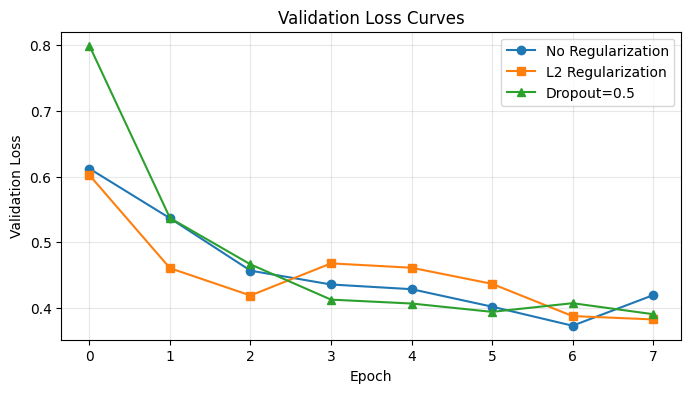

In [7]:
# 绘制验证损失曲线
plt.figure(figsize=(8, 4))
plt.plot(plain_hist['val_loss'], marker='o', label='No Regularization')
plt.plot(l2_hist['val_loss'], marker='s', label='L2 Regularization')
plt.plot(drop_hist['val_loss'], marker='^', label='Dropout=0.5')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4 数值稳定性和激活函数

### 4.1 理论计算题

<img src="./hw02_pic/4-1.png" width="600">

2.  Sigmoid 函数其导数最大只有 0.25，并且当输入很大或很小时，函数进入饱和区，导数会接近 0。因此在深层网络反向传播时，梯度会不断乘以很小的数，容易发生梯度消失。而 ReLU 在输入大于 0 时，导数恒为 1。此时反向传播的梯度不会因为激活函数导数小于 1 而被持续缩小。因此，在神经元被激活的区域，ReLU 能够让梯度更稳定地向前层传播，梯度不会因为激活函数本身而指数级衰减。


### 4.2 编程题

In [8]:
def build_deep_net(activation='sigmoid', depth=20, width=256, in_dim=256, out_dim=10):
    layers = []
    dims = [in_dim] + [width] * (depth - 1) + [out_dim]
    act_layer = nn.Sigmoid if activation == 'sigmoid' else nn.ReLU

    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:
            layers.append(act_layer())
    return nn.Sequential(*layers).to(device)

def init_normal(model, std=1.0):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=std)
            nn.init.zeros_(m.bias)

def init_xavier(model, leaky=False):
    gain = nn.init.calculate_gain('leaky_relu' if leaky else 'relu')
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight, gain=gain)
            nn.init.zeros_(m.bias)

def grad_norms(model):
    norms = []
    for m in model.modules():
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            norms.append(m.weight.grad.norm().item())
    return norms

def one_backward(model, clip=False):
    X = torch.randn(128, 256, device=device)
    y = torch.randint(0, 10, (128,), device=device)
    criterion = nn.CrossEntropyLoss()

    out = model(X)
    loss = criterion(out, y)
    loss.backward()

    if clip:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1e3)
        for p in model.parameters():
            if p.grad is not None:
                p.grad.data.clamp_(-1e3, 1e3)

    return loss.item(), grad_norms(model), torch.isnan(out).any().item()


In [9]:

net_sig = build_deep_net(activation='sigmoid', depth=20, width=256)
init_normal(net_sig, std=1.0)
loss_sig, norms_sig, has_nan_sig = one_backward(net_sig, clip=False)
print('Sigmoid/std=1 loss:', loss_sig, 'NaN:', has_nan_sig)
print('Gradient norms (first 10 layers):', norms_sig[:10])


net_relu_bad = build_deep_net(activation='relu', depth=20, width=256)
init_normal(net_relu_bad, std=10.0)
loss_bad, norms_bad, has_nan_bad = one_backward(net_relu_bad, clip=False)
print('ReLU/std=10 loss:', loss_bad, 'NaN:', has_nan_bad)
print('Gradient norms (first 10 layers):', norms_bad[:10])


net_relu_good = build_deep_net(activation='relu', depth=20, width=256)
init_xavier(net_relu_good, leaky=False)
loss_good, norms_good, has_nan_good = one_backward(net_relu_good, clip=True)
print('Xavier+ReLU+Clip loss:', loss_good, 'NaN:', has_nan_good)
print('Gradient norms (first 10 layers):', norms_good[:10])


Sigmoid/std=1 loss: 19.486658096313477 NaN: False
Gradient norms (first 10 layers): [108.47071838378906, 69.73524475097656, 56.70901870727539, 44.09337615966797, 37.212066650390625, 31.402278900146484, 23.824546813964844, 22.0343074798584, 18.138391494750977, 14.743437767028809]
ReLU/std=10 loss: nan NaN: True
Gradient norms (first 10 layers): [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Xavier+ReLU+Clip loss: 2.8422956466674805 NaN: False
Gradient norms (first 10 layers): [1.540260910987854, 1.7745965719223022, 1.9581222534179688, 1.992112398147583, 2.1812386512756348, 2.5418906211853027, 2.85447359085083, 3.1877453327178955, 3.3844423294067383, 3.2116587162017822]


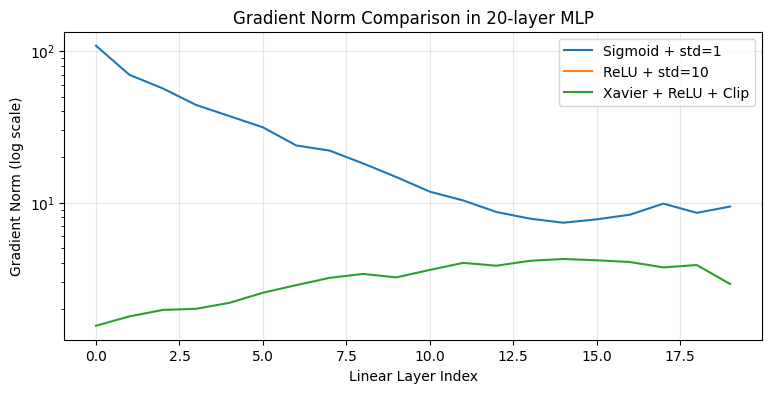

In [10]:
plt.figure(figsize=(9, 4))
plt.plot(norms_sig, label='Sigmoid + std=1')
plt.plot(norms_bad, label='ReLU + std=10')
plt.plot(norms_good, label='Xavier + ReLU + Clip')
plt.yscale('log')
plt.xlabel('Linear Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Norm Comparison in 20-layer MLP')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

协变量偏移是指训练集和测试集的输入特征分布不同，但标签生成规律不变。比如在语音识别中，训练数据主要来自安静环境，而测试数据来自嘈杂环境，语音信号分布发生变化，但同一句话对应的文字不变，因此属于协变量偏移。

标签偏移是指训练集和测试集的标签分布不同，但在给定标签的情况下，输入特征分布不变。比如在医疗场景中，平时感冒、胃痛等患者比例较均衡，但流感季节呼吸道疾病患者明显增多，此时疾病类别比例发生变化，但同一种疾病对应的症状表现基本不变，因此属于标签偏移。

二者的区别在于：协变量偏移主要是输入 (x) 的分布发生变化，而标签偏移主要是标签 (y) 的分布发生变化。

二者的联系在于：它们都属于训练分布和测试分布不一致的问题，都会影响模型在测试集上的泛化能力，也都可以通过重新加权等方法进行一定程度的校正。



### 5.2 编程题


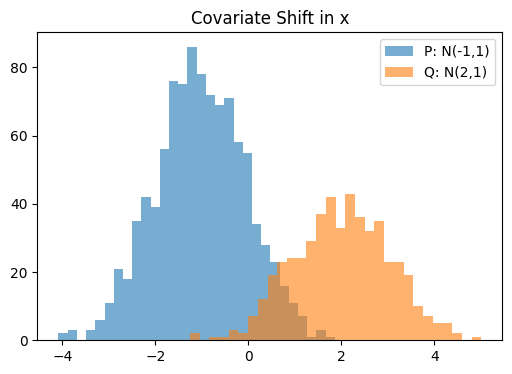

In [11]:
# 1) 生成数据集
set_seed(7)
n_p, n_q = 1000, 500
x_p = np.random.normal(loc=-1.0, scale=1.0, size=(n_p, 1))
x_q = np.random.normal(loc=2.0, scale=1.0, size=(n_q, 1))

noise_p = np.random.normal(loc=0.0, scale=0.2, size=(n_p, 1))
noise_q = np.random.normal(loc=0.0, scale=0.2, size=(n_q, 1))
y_p = 2 * x_p + noise_p
y_q = 2 * x_q + noise_q

plt.figure(figsize=(6, 4))
plt.hist(x_p, bins=30, alpha=0.6, label='P: N(-1,1)')
plt.hist(x_q, bins=30, alpha=0.6, label='Q: N(2,1)')
plt.title('Covariate Shift in x')
plt.legend()
plt.show()


In [12]:
# 2) 训练回归模型
class LinearReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(1, 1)
    def forward(self, x):
        return self.lin(x)

def train_regression(x_train, y_train, sample_weight=None, lr=0.05, epochs=500):
    model = LinearReg().to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    xt = torch.tensor(x_train, dtype=torch.float32, device=device)
    yt = torch.tensor(y_train, dtype=torch.float32, device=device)
    if sample_weight is None:
        wt = torch.ones_like(yt)
    else:
        wt = torch.tensor(sample_weight, dtype=torch.float32, device=device).reshape(-1, 1)

    for _ in range(epochs):
        pred = model(xt)
        loss = ((pred - yt) ** 2 * wt).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()

    return model

def mse(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, device=device)
    y = torch.tensor(y, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred = model(x)
        return ((pred - y) ** 2).mean().item()

# 训练不加权模型
model_plain = train_regression(x_p, y_p, sample_weight=None)
mse_plain = mse(model_plain, x_q, y_q)
print(f'Unweighted -> Test MSE on Q: {mse_plain:.4f}')

# 3) 训练域适应模型
x_domain = np.vstack([x_p, x_q])
y_domain = np.vstack([np.zeros((n_p, 1)), np.ones((n_q, 1))])

domain_net = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid()).to(device)
opt_d = torch.optim.Adam(domain_net.parameters(), lr=0.01)
bce = nn.BCELoss()

xd = torch.tensor(x_domain, dtype=torch.float32, device=device)
yd = torch.tensor(y_domain, dtype=torch.float32, device=device)

for _ in range(400):
    p_test = domain_net(xd)
    loss_d = bce(p_test, yd)
    opt_d.zero_grad()
    loss_d.backward()
    opt_d.step()

with torch.no_grad():
    p_test_on_p = domain_net(torch.tensor(x_p, dtype=torch.float32, device=device)).cpu().numpy()

# 计算重要性权重并训练加权模型
eps = 1e-6
weights = p_test_on_p / (1.0 - p_test_on_p + eps)
weights = np.clip(weights, 1e-3, 1e3)
weights = weights / weights.mean()

model_weighted = train_regression(x_p, y_p, sample_weight=weights)
mse_weighted = mse(model_weighted, x_q, y_q)
print(f'Importance Weighted -> Test MSE on Q: {mse_weighted:.4f}')


Unweighted -> Test MSE on Q: 0.0396
Importance Weighted -> Test MSE on Q: 0.0460
